In [4]:
!pip install pydicom opencv-python tqdm


In [5]:
import torch
print(torch.cuda.is_available())

True


In [6]:
import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


In [7]:
BASE_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection"
DICOM_PATH = os.path.join(BASE_PATH, "train")
CSV_PATH = os.path.join(BASE_PATH, "train.csv")

OUTPUT_IMAGE_PATH = "/kaggle/working/images"
OUTPUT_LABEL_PATH = "/kaggle/working/labels"

os.makedirs(OUTPUT_IMAGE_PATH, exist_ok=True)
os.makedirs(OUTPUT_LABEL_PATH, exist_ok=True)


In [8]:
os.listdir(BASE_PATH)  #To check the datasets in BASE_PATH


['sample_submission.csv', 'train.csv', 'test', 'train']

In [9]:
def dicom_to_png(dicom_path, output_path, limit=5000):
    files = os.listdir(dicom_path)
    count = 0
    
    for file in tqdm(files):
        if file.endswith(".dicom") or file.endswith(".dcm"):    #Convert first 1000 images to PNG format out of 15000 images
            
            if count >= limit:   # Hard stop condition
                break
            
            full_path = os.path.join(dicom_path, file)
            
            try:
                dcm = pydicom.dcmread(full_path)
                img = dcm.pixel_array
                
                # Normalize safely
                img = img - np.min(img)
                if np.max(img) != 0:
                    img = img / np.max(img)
                
                img = (img * 255).astype(np.uint8)
                
                output_file = file.replace(".dicom", ".png").replace(".dcm", ".png")
                cv2.imwrite(os.path.join(output_path, output_file), img)
                
                count += 1
            
            except Exception as e:
                print(f"Error with {file}: {e}")

    print(f"Total converted: {count}")

dicom_to_png(DICOM_PATH, OUTPUT_IMAGE_PATH, limit=5000)

 33%|███▎      | 5000/15000 [1:20:32<2:41:05,  1.03it/s]

Total converted: 5000


Converted sample image


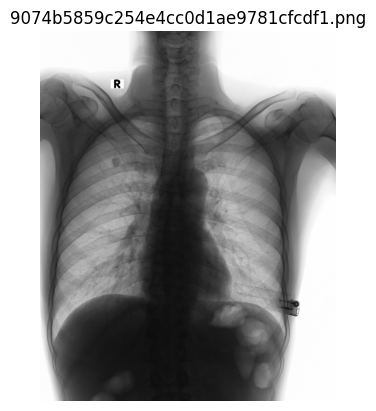

In [10]:
sample_img = os.listdir(OUTPUT_IMAGE_PATH)[1]
img = cv2.imread(os.path.join(OUTPUT_IMAGE_PATH, sample_img), 0)

plt.imshow(img, cmap='gray')
plt.rcParams["figure.figsize"] = (7, 7)
plt.title(sample_img)
plt.axis("off")
print("Converted sample image")
plt.show()


In [11]:
df = pd.read_csv(CSV_PATH)
df.head()


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [12]:
classes = df['class_name'].unique()
class_dict = {name: i for i, name in enumerate(classes)}

print(class_dict)


{'No finding': 0, 'Cardiomegaly': 1, 'Aortic enlargement': 2, 'Pleural thickening': 3, 'ILD': 4, 'Nodule/Mass': 5, 'Pulmonary fibrosis': 6, 'Lung Opacity': 7, 'Atelectasis': 8, 'Other lesion': 9, 'Infiltration': 10, 'Pleural effusion': 11, 'Calcification': 12, 'Consolidation': 13, 'Pneumothorax': 14}


In [13]:
grouped = df.groupby("image_id")

for image_id, group in tqdm(grouped):
    
    img_file = os.path.join(OUTPUT_IMAGE_PATH, image_id + ".png")
    
    if not os.path.exists(img_file):
        continue
    
    img = cv2.imread(img_file)
    h, w, _ = img.shape
    
    label_file = os.path.join(OUTPUT_LABEL_PATH, image_id + ".txt")
    
    with open(label_file, "w") as f:
        for _, row in group.iterrows():
            
            # Skip No Finding (NaN boxes)
            if pd.isna(row.x_min):
                continue
            
            x_center = ((row.x_min + row.x_max) / 2) / w
            y_center = ((row.y_min + row.y_max) / 2) / h
            width = (row.x_max - row.x_min) / w
            height = (row.y_max - row.y_min) / h
            
            class_id = class_dict[row.class_name]
            
            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")


100%|██████████| 15000/15000 [05:43<00:00, 43.65it/s]


In [ ]:
import os

for file in os.listdir(OUTPUT_LABEL_PATH)[:20]:
    path = os.path.join(OUTPUT_LABEL_PATH, file)
    
    if os.path.getsize(path) > 0:
        print("Found non-empty label file:", file)
        with open(path) as f:
            print(f.read())
        break


Found non-empty label file: 15f023463d88b8f8bc852a9a7b72e6e3.txt
13 0.7534763607469209 0.5678615196078431 0.30552244735796585 0.42432598039215685
13 0.25764799364322605 0.5318627450980392 0.3230035756853397 0.5202205882352942
13 0.7361938816050854 0.5957414215686274 0.33134684147794996 0.4206495098039216
3 0.3267779102105681 0.21798406862745098 0.1855383392928089 0.045649509803921566
7 0.7361938816050854 0.5957414215686274 0.33134684147794996 0.4206495098039216
7 0.25764799364322605 0.5318627450980392 0.3230035756853397 0.5202205882352942
9 0.797377830750894 0.7919730392156863 0.1764004767580453 0.11090686274509803
7 0.7534763607469209 0.5678615196078431 0.30552244735796585 0.42432598039215685
2 0.5818434644417958 0.35401348039215685 0.11640842272546682 0.0897671568627451
7 0.24056416368692887 0.5520833333333334 0.354787445371474 0.5238970588235294
3 0.6835518474374255 0.2106311274509804 0.15534366309098133 0.05361519607843137
3 0.32995629717918157 0.21629901960784315 0.139451728247914

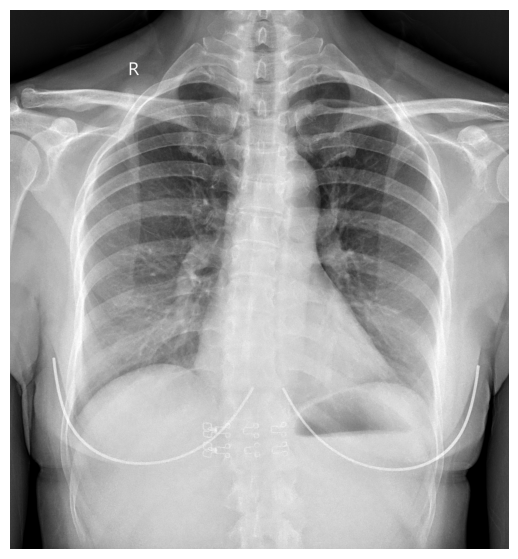

In [ ]:
sample_img = os.listdir(OUTPUT_IMAGE_PATH)[7]  
img = cv2.imread(os.path.join(OUTPUT_IMAGE_PATH, sample_img))

h, w, _ = img.shape            #To check if any abnormalities found in the image the bounding box correctly displays it

label_path = os.path.join(OUTPUT_LABEL_PATH, sample_img.replace(".png", ".txt"))

if os.path.exists(label_path):
    with open(label_path) as f:
        lines = f.readlines()
        
    for line in lines:
        class_id, xc, yc, bw, bh = map(float, line.split())
        
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.rcParams["figure.figsize"] = (7, 7)
plt.show()


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Paths
INPUT_FOLDER = OUTPUT_IMAGE_PATH          # Your converted PNG images
PROCESSED_FOLDER = "/kaggle/working/processed_images"

os.makedirs(PROCESSED_FOLDER, exist_ok=True)

TARGET_SIZE = 640

# -------- Crop Function --------
def crop_black_borders(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
        
    _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]
        
    return img


# -------- Processing Loop --------
for image_name in tqdm(os.listdir(INPUT_FOLDER)):
    
    image_path = os.path.join(INPUT_FOLDER, image_name)
    img = cv2.imread(image_path)
    
    if img is None:
        continue
    
    # 1. Convert to Grayscale
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2️. Crop Borders
    img = crop_black_borders(img)
    
    # 3️. Resize
    img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE))
    
    # 4️. CLAHE (Light Contrast Enhancement)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    
    # 5️. Light Denoising (Gaussian Blur)
    img = cv2.GaussianBlur(img, (3,3), 0)
    
    # Save processed image
    save_path = os.path.join(PROCESSED_FOLDER, image_name)
    cv2.imwrite(save_path, img)

print("Preprocessing Completed Successfully!")


100%|██████████| 5000/5000 [14:27<00:00,  5.76it/s]

Preprocessing Completed Successfully!


Image shape: (640, 640)


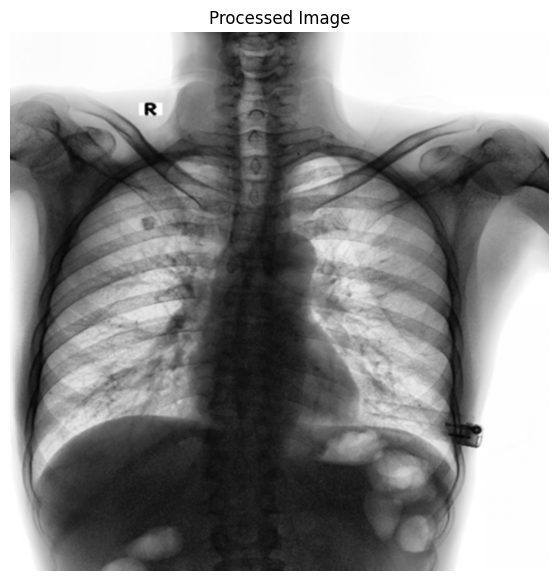

In [21]:
import matplotlib.pyplot as plt

# Pick one processed image
sample_img = os.listdir(PROCESSED_FOLDER)[1]
img_path = os.path.join(PROCESSED_FOLDER, sample_img)

img = cv2.imread(img_path, 0)

print("Image shape:", img.shape)

plt.figure(figsize=(7,7))
plt.imshow(img, cmap='gray')
plt.title("Processed Image")
plt.axis("off")
plt.show()


In [23]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Base directory
BASE_DIR = "/kaggle/working/yolo_dataset"
os.makedirs(BASE_DIR, exist_ok=True)

# Create folder structure
for folder in [
    "images/train", "images/val", "images/test",
    "labels/train", "labels/val", "labels/test"
]:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

In [24]:
IMAGE_FOLDER = PROCESSED_FOLDER
LABEL_FOLDER = OUTPUT_LABEL_PATH

# Get all images
images = os.listdir(IMAGE_FOLDER)

# Split dataset
train_imgs, temp_imgs = train_test_split(
    images, test_size=0.3, random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs, test_size=0.33, random_state=42
)

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))



Train: 3500
Val: 1005
Test: 495


In [25]:
def move_files(image_list, split_type):
    for img_name in image_list:
        
        # Move image
        src_img = os.path.join(IMAGE_FOLDER, img_name)
        dst_img = os.path.join(BASE_DIR, "images", split_type, img_name)
        shutil.copy(src_img, dst_img)

        # Move corresponding label
        label_name = img_name.replace(".png", ".txt")
        src_label = os.path.join(LABEL_FOLDER, label_name)

        if os.path.exists(src_label):
            dst_label = os.path.join(BASE_DIR, "labels", split_type, label_name)
            shutil.copy(src_label, dst_label)


# Execute splits
move_files(train_imgs, "train")
move_files(val_imgs, "val")
move_files(test_imgs, "test")

print("Dataset split completed!")

Dataset split completed!


In [26]:
import shutil

source_folder = "/kaggle/working/processed_images"
zip_path = "/kaggle/working/processed_images.zip"

shutil.make_archive(
    "/kaggle/working/processed_images",
    'zip',
    source_folder
)

print("Preprocessed images zipped successfully.")

Preprocessed images zipped successfully.


In [27]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score

In [28]:
# Load CSV
df = pd.read_csv("/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv")

# Group labels per image
grouped = df.groupby("image_id")["class_name"].apply(list).reset_index()

# Multi-label encoding
mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(grouped["class_name"])
grouped["encoded_labels"] = list(labels)

# Create image paths
image_dir = "/kaggle/working/processed_images"

grouped["image_path"] = grouped["image_id"].apply(
    lambda x: os.path.join(image_dir, x + ".png")
)

# Remove missing images
grouped = grouped[grouped["image_path"].apply(os.path.exists)]

print("Total images:", len(grouped))

Total images: 5000


In [29]:
train_df, val_df = train_test_split(
    grouped,
    test_size=0.2,
    random_state=42
)

train_paths = train_df["image_path"].tolist()
train_labels = train_df["encoded_labels"].tolist()

val_paths = val_df["image_path"].tolist()
val_labels = val_df["encoded_labels"].tolist()

print("Train:", len(train_paths))
print("Validation:", len(val_paths))

Train: 4000
Validation: 1000


In [31]:
class ChestXrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = torch.FloatTensor(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

In [32]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # 🔥 Classification size
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [33]:
train_dataset = ChestXrayDataset(train_paths, train_labels, transform)
val_dataset = ChestXrayDataset(val_paths, val_labels, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights="DEFAULT")

num_features = model.fc.in_features
num_classes = len(train_labels[0])

model.fc = nn.Linear(num_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s] 


In [36]:
labels_array = np.array(train_labels)

pos_weight = torch.tensor(
    (len(labels_array) - labels_array.sum(axis=0)) /
    (labels_array.sum(axis=0) + 1e-6)
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [37]:
num_epochs = 5
best_f1 = 0

for epoch in range(num_epochs):

    # ---- TRAIN ----
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.sigmoid(outputs)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(labels.cpu().numpy())

    val_loss /= len(val_loader)

    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    binary_preds = (all_preds > 0.5).astype(int)

    f1 = f1_score(all_targets, binary_preds,
                  average="macro",
                  zero_division=0)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"F1 Score: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_classification_model.pth")
        print("✅ Best model saved!")


Epoch 1/5
Train Loss: 1.1662
Val Loss: 0.9566
F1 Score: 0.2208
✅ Best model saved!

Epoch 2/5
Train Loss: 1.0459
Val Loss: 1.0011
F1 Score: 0.1889

Epoch 3/5
Train Loss: 1.0876
Val Loss: 0.8867
F1 Score: 0.2312
✅ Best model saved!

Epoch 4/5
Train Loss: 0.9579
Val Loss: 0.8592
F1 Score: 0.2420
✅ Best model saved!

Epoch 5/5
Train Loss: 0.9119
Val Loss: 0.9034
F1 Score: 0.2350


In [41]:
!pip install ultralytics -q

In [40]:
import yaml

# your class_dict from earlier
# example: {'Aortic enlargement':0, 'Atelectasis':1, ...}

data = {
    'train': '/kaggle/working/yolo_dataset/images/train',
    'val': '/kaggle/working/yolo_dataset/images/val',
    'test': '/kaggle/working/yolo_dataset/images/test',
    'nc': len(class_dict),
    'names': list(class_dict.keys())
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data, f)

print("data.yaml created")

data.yaml created


In [43]:
import torch
torch.use_deterministic_algorithms(False)

In [44]:
from ultralytics import YOLO

# Load medium model (recommended)
model = YOLO('yolov8m.pt')

# Train for 20 epochs
model.train(
    data='/kaggle/working/data.yaml',
    epochs=20,        # 👈 set to 20
    imgsz=640,
    batch=8,
    device=0,
    lr0=0.001,
    degrees=10,       # small rotation (medical safe)
    fliplr=0.5,       # horizontal flip allowed
    hsv_h=0,
    hsv_s=0,
    hsv_v=0,
    perspective=0,
    shear=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0, hsv_s=0, hsv_v=0, imgsz=640, int8=False, iou=0.7,

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2218.8±1401.2 MB/s, size: 208.6 KB)
train: Scanning /kaggle/working/yolo_dataset/labels/train... 3500 images, 2481 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3500/3500 638.8it/s 5.5s<0.0s
train: New cache created: /kaggle/working/yolo_dataset/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 829.3±692.7 MB/s, size: 194.6 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val... 1005 images, 723 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1005/1005 585.9it/s 1.7s1s
val: New cache created: /kaggle/working/yolo_dataset/labels/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optim

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


       1/20      3.85G      2.149      4.813      2.122          6        640: 100% ━━━━━━━━━━━━ 438/438 3.7it/s 1:59<0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.4it/s 14.2s0.2s
                   all       1005       2385      0.717     0.0499     0.0398     0.0153

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      4.44G      2.352      3.813      1.873         25        640: 0% ──────────── 0/438  0.3s

...

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      19/20      6.35G      1.486      2.127      1.703         17        640: 100% ━━━━━━━━━━━━ 438/438 3.7it/s 1:60<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.6it/s 13.8s0.2s
                   all       1005       2385      0.338      0.201      0.191     0.0898

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/20      6.79G          0      1.416          0          0        640: 0% ──────────── 0/438  0.2s

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:384: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      20/20      6.82G      1.508      1.988      1.694         12        640: 100% ━━━━━━━━━━━━ 438/438 3.7it/s 1:60<0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.6it/s 13.8s0.2s
                   all       1005       2385       0.36      0.223      0.198     0.0931

20 epochs completed in 0.748 hours.
Optimizer stripped from /kaggle/working/runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from /kaggle/working/runs/detect/train/weights/best.pt, 52.0MB

Validating /kaggle/working/runs/detect/train/weights/best.pt...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,848,445 parameters, 0 gradients, 78.7 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.6it/s 13.7s0.2s
                   all       1005       2385      0.361      0.222      0.197      0.093
    

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba876c750a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [45]:
metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,848,445 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2161.9±977.2 MB/s, size: 195.3 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 1005 images, 723 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1005/1005 145.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 2.7it/s 23.5s0.4ss
                   all       1005       2385      0.365      0.225      0.199     0.0938
          Cardiomegaly        151        349      0.708      0.396      0.557      0.329
    Aortic enlargement        201        479      0.638      0.572      0.652      0.377
    Pleural thickening        134        380      0.236      0.179      0.118     0.0355
                   ILD         30         74      0.278      0.432      0.305      0.117
           Nodule/Mass   

In [48]:
image_dir = "/kaggle/working/yolo_dataset/images/val"
image_files = os.listdir(image_dir)

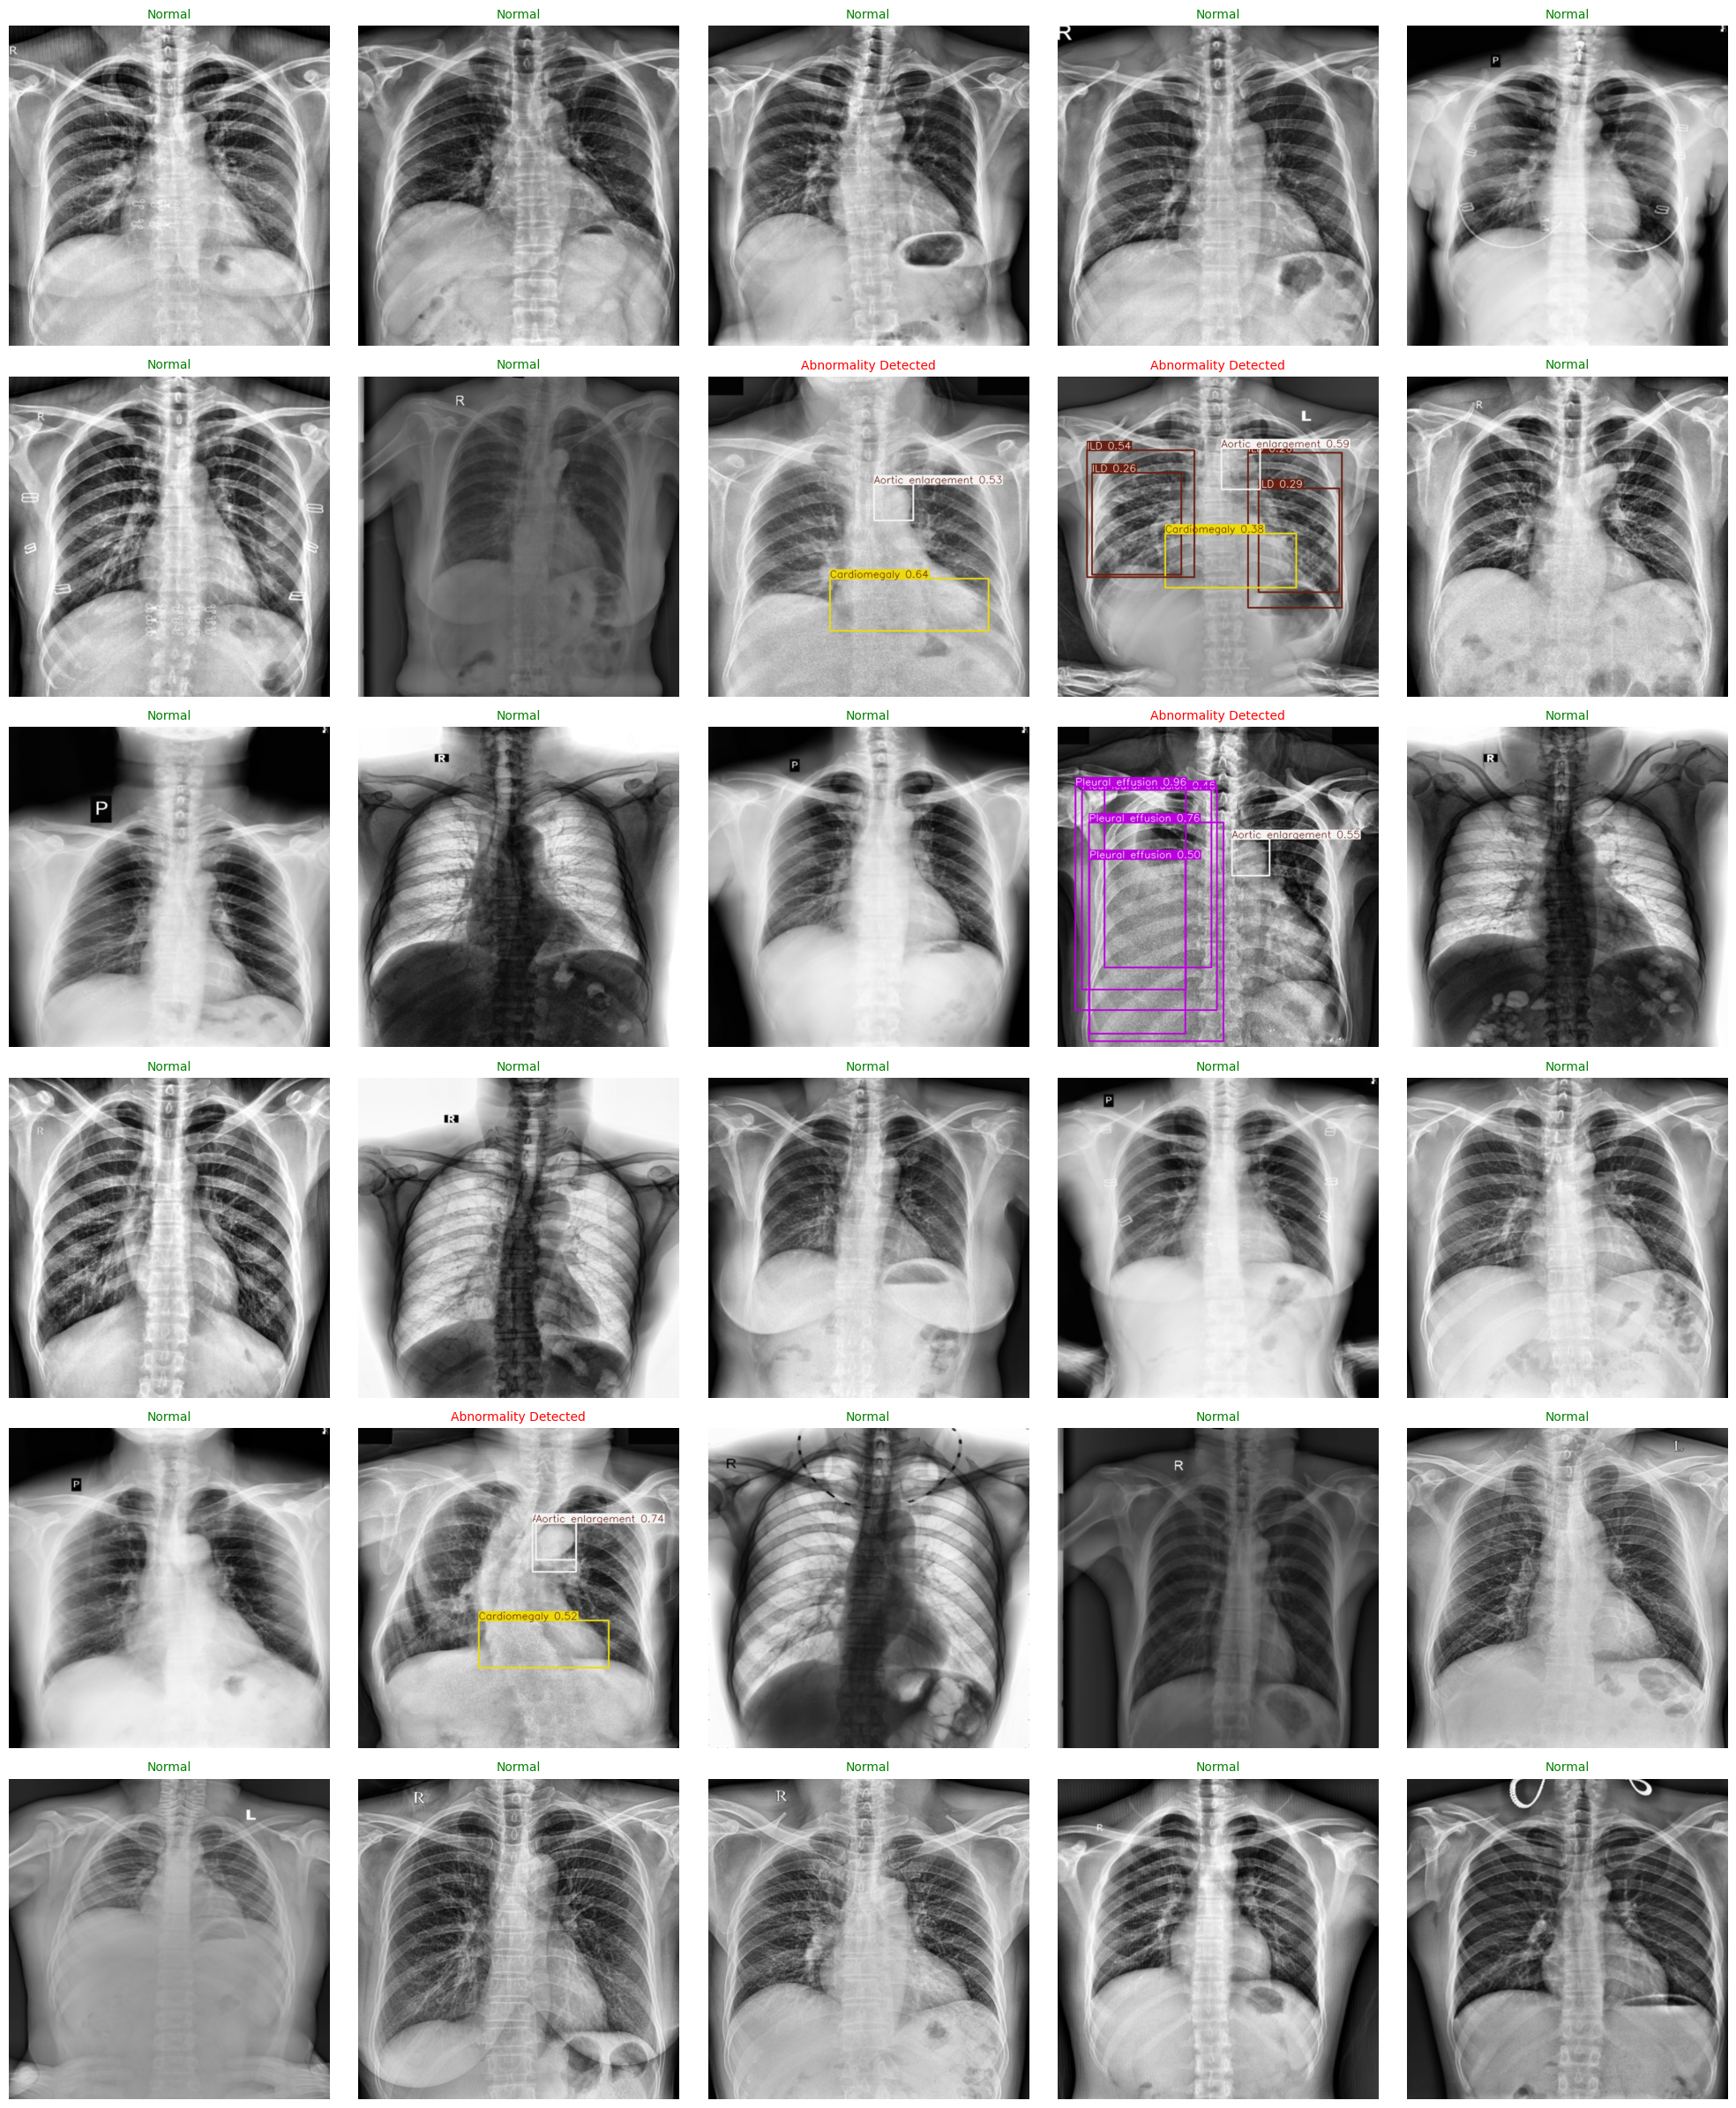

In [52]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
from PIL import Image

# Load trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Validation images folder
image_dir = "/kaggle/working/yolo_dataset/images/val"
image_files = os.listdir(image_dir)

num_images = 30
cols = 5
rows = 6

plt.figure(figsize=(20,24))

for i, img_name in enumerate(image_files[:num_images]):

    img_path = os.path.join(image_dir, img_name)

    # Run detection
    results = model.predict(img_path, conf=0.25, verbose=False)

    plt.subplot(rows, cols, i+1)

    if len(results[0].boxes) > 0:

        plotted_img = results[0].plot()
        plt.imshow(plotted_img)

        plt.title("Abnormality Detected", fontsize=10, color="red")

    else:

        img = Image.open(img_path)
        plt.imshow(img, cmap="gray")

        plt.title("Normal", fontsize=10, color="green")

    plt.axis("off")

plt.tight_layout()
plt.show()